# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Christine Swanson 

**ID**: cms549

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Packages

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2003]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure (similar to DataFrames)
import numpy as np  # numerical operations
import csv  # reads/writes .csv files
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
from datetime import datetime, timedelta  # date and time handling
from scipy.stats import genextreme, poisson, genpareto # for GEV, Poisson, GPD distributions 
from scipy.optimize import minimize # for MLE 
from sklearn.linear_model import LinearRegression # linear regression for problem 3
import statsmodels.api as sm # for AIC calculations

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

In [2004]:
# set the seed
np.random.seed(44)

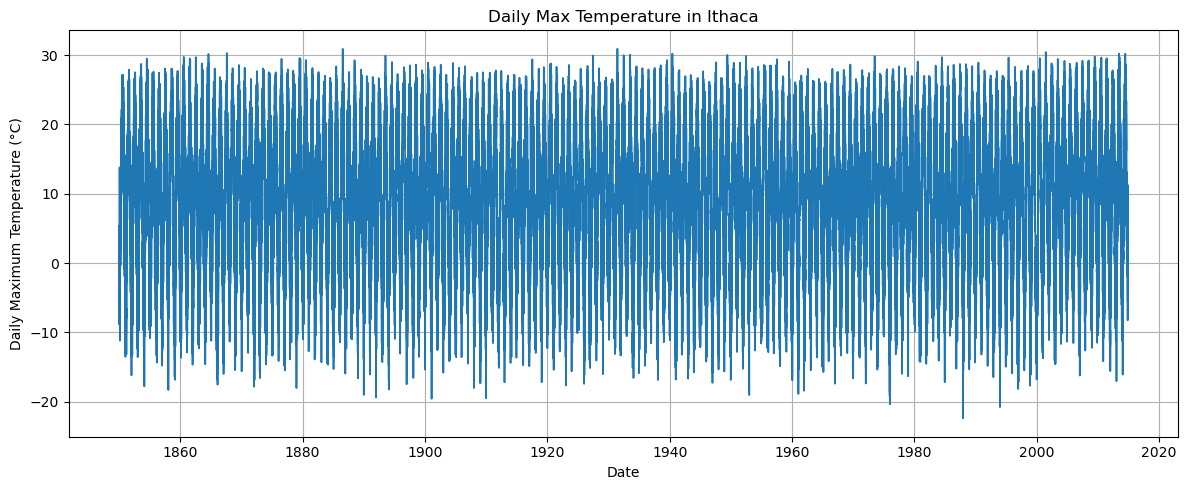

In [2005]:
# adapted from ChatGPT (see references)
# read the CSV file into a DataFrame
ithaca_dat = pd.read_csv("data/gfdl-esm4-tempmax-ithaca.csv")

# convert the 'Day' column to datetime
ithaca_dat['Day'] = pd.to_datetime(ithaca_dat['Day'])

# plot the data
plt.figure(figsize=(12, 5))
plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], linewidth=1.25)
plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?


#### **Plotting the Annual Maximum Temperatures:**

In [2006]:
# after loading the data, find the modeled annual maximum temperature and plot them

# find modeled annual max temp 
# make a year column
ithaca_dat["Year"] = ithaca_dat["Day"].dt.year

# compute annual maxima and the corresponding dates
annual_maxima = ithaca_dat.loc[ithaca_dat.groupby('Year')['TempMax'].idxmax()]

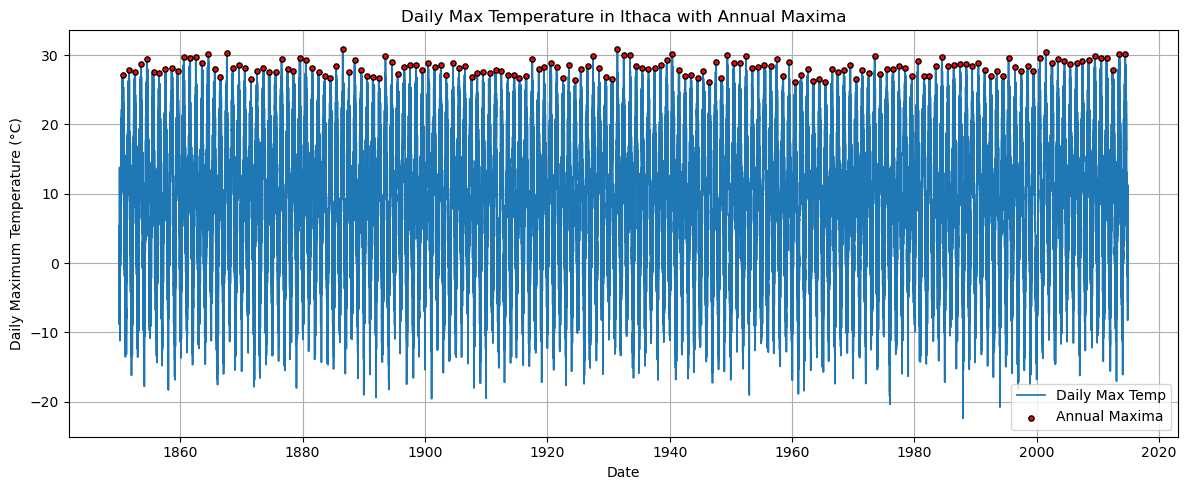

In [2007]:
# plot the daily data
plt.figure(figsize=(12, 5))

plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], 
         linewidth=1.25, label='Daily Max Temp')

# plot the annual maxima (points)
plt.scatter(annual_maxima['Day'], annual_maxima['TempMax'], 
            color='red', label='Annual Maxima', zorder=5,
            s=14, edgecolor = "black")

plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca with Annual Maxima")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

#### **Stationary GEV Model:**

In [2008]:
# fit a stationary GEV model to the annual maximum series 
# and report parameter estimates

# list of the annual maxima data
annual_max_data = annual_maxima['TempMax'].values

# negative log-likelihood function for stationary GEV
# scipy.optimize minimizes the negative log-likelihood 

def gev_negloglik(params):
    # unpack GEV parameters: shape, loc, scale
    c, loc, scale = params

    # make sure scale is positive
    if scale <= 0:
        return np.inf

    # compute negative log likelihood
    return -np.sum(genextreme.logpdf(annual_max_data, 
                                     c=c, loc=loc, scale=scale))

# initial guesses for parameters: [shape, location, scale]
init_param_vals = [0.1, np.mean(annual_max_data), np.std(annual_max_data)]
bounds = [(-1.0, 1.0), (-100, 100), (1e-6, 100)]

# optimize using scipy.optimize.minimize
# Julia default method is Nelder-Mead
result = minimize(gev_negloglik, init_param_vals, 
                  bounds = bounds, method='Nelder-Mead') 

# extract estimated parameters
shape_mle, loc_mle, scale_mle = result.x

# print the estimated parameters from stationary GEV fit
print("---Stationary GEV MLE Parameters:---")
print(f"Shape (ξ): {-shape_mle:.2f}")
print(f"Location (μ): {loc_mle:.2f}")
print(f"Scale (σ): {scale_mle:.2f}")

---Stationary GEV MLE Parameters:---
Shape (ξ): -0.22
Location (μ): 27.83
Scale (σ): 1.02


In [2009]:
# generate a range of x values for plotting the PDF
x_vals = np.linspace(min(annual_max_data), 
                     max(annual_max_data), 500)

# get the fitted PDF using MLE parameters (note: scipy uses shape = -ξ)
fitted_pdf = genextreme.pdf(x_vals, c=shape_mle, loc=loc_mle, scale=scale_mle)

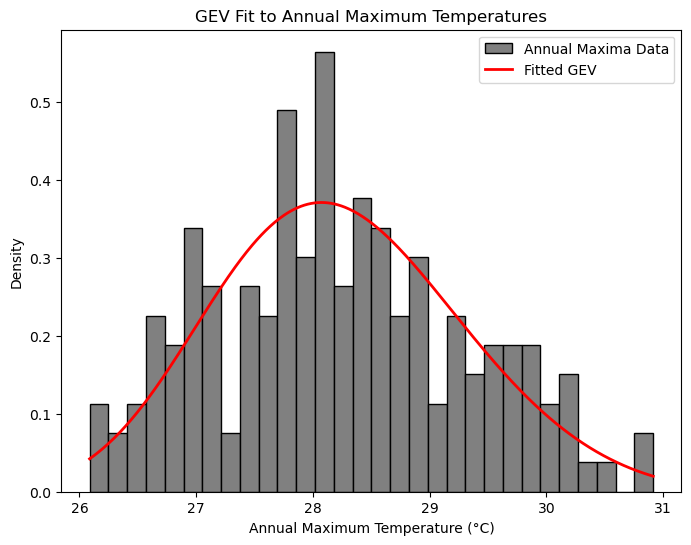

In [2010]:
# plot the fitted distribution along with the data
# need to overlay the fitted GEV on the data

plt.figure(figsize=(8, 6)) 

# annual maxima data
plt.hist(annual_max_data, bins=30, density = True, color = "grey", 
         label = "Annual Maxima Data", edgecolor="black")

# fitted GEV
plt.plot(x_vals, fitted_pdf, 'red', lw=2, label="Fitted GEV")

plt.xlabel("Annual Maximum Temperature (°C)")
plt.ylabel("Density")
plt.title("GEV Fit to Annual Maximum Temperatures")
plt.legend()

plt.show()

In [2011]:
# compute the 100-year return level

# given MLE values for location (mu), scale (sigma), and shape (xi)
T = 100  # return period (years)
p = 1 - 1/T  # non-exceedance probability

# compute 100-year return level using quantile at 0.99
return_lvl_100 = genextreme.ppf(p, c=shape_mle, loc=loc_mle, scale=scale_mle)

# print 100-year return level
print(f"100-year return level (stationary GEV model): {return_lvl_100:.2f} °C")

100-year return level (stationary GEV model): 30.78 °C


*Question: What type of GEV distribution did you end up with? What is the 100-year return level?*

**RESPONSE: The parameter estimates I got from my fitted GEV to the annual maxima are: Shape (ξ): -0.22; Location (μ): 27.83; Scale (σ): 1.02. Because scipy's `genextreme` function shape parameter is the *negative* of the standard GEV shape parameter, this means the GEV distribution I ended up with is a Weibull distribution (ξ < 0). This means the distribution is bounded on the upper bound, which we can see from the above plot. The 100-year return level is 30.78 °C. This means that 30.78 °C is the temperature expected to be exceeded only once every 100 years, on average, based on the extreme temperature data I used to fit my stationary GEV model.**

#### **Non-Stationary GEV Model:**

In [2012]:
# fit non-stationary GEV with respect to time 
# (only the location parameter should be non-stationary),
# # $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
# purposes, begin with $t=0$ corresponding to 1850)

# list of the annual maxima data
annual_max_data = annual_maxima['TempMax'].values

# define time variable starting from t=0 
# corresponding to the year 1850
years = np.arange(1850, 1850 + len(annual_max_data))

# non-stationary GEV log-likelihood function
# loc: μ(t) = μ0 + μ1*t
def gev_negloglik_nonstationary(params):
    mu_0, mu_1, sigma, xi = params
    
    # compute location parameter μ(t) (non-stationary)
    mu_t = mu_0 + mu_1 * years
    
    # make sure sigma > 0 
    if sigma <= 0:
        return np.inf

    # compute the negative log-likelihood
    log_likelihood = -np.sum(genextreme.logpdf(annual_max_data, 
                                               c=xi, loc=mu_t, scale=sigma))
    
    return log_likelihood

# initial guesses for parameters: [mu0, mu1, sigma, xi]
init_param_vals = [np.mean(annual_max_data), 0.0, np.std(annual_max_data), 0.1]

# optimize the log-likelihood function using scipy's minimize
result_nonstationary = minimize(gev_negloglik_nonstationary, 
                                init_param_vals, method='Nelder-Mead')

# extract the estimated parameters
mu_0_mle, mu_1_mle, sigma_mle, xi_mle = result_nonstationary.x

# print the estimated parameters -> non-stationary GEV model
print("---Non-Stationary GEV MLE Parameters:---")
print(f"loc 0 (mu_0): {mu_0_mle:.2f}")
print(f"loc 1 (mu_1): {mu_1_mle:.3f}")
print(f"Scale (σ): {sigma_mle:.2f}")
print(f"Shape (ξ): {xi_mle:.2f}")

---Non-Stationary GEV MLE Parameters:---
loc 0 (mu_0): 23.91
loc 1 (mu_1): 0.002
Scale (σ): 1.02
Shape (ξ): 0.22


#### **Model Comparison (AIC) - Stationary and Non-Stationary GEV Models:**

In [2013]:
# compute the AIC for each of the models 
# (stationary and nonstationary GEV models)

# AIC = 2*k - 2(ll)
# where k is number of params
# ll is log-likelihood 

nll_stationary = gev_negloglik(result.x) 
k_stationary = 3
aic_stationary = 2 * k_stationary - 2 * -nll_stationary
print(f"AIC for Stationary GEV: {aic_stationary:.2f}")

nll_nonstationary = gev_negloglik_nonstationary(result_nonstationary.x)
k_nonstationary = 4
aic_nonstationary = 2 * k_nonstationary - 2 * -nll_nonstationary
print(f"AIC for Non-Stationary GEV: {aic_nonstationary:.2f}")

AIC for Stationary GEV: 492.93
AIC for Non-Stationary GEV: 493.59


*Question: What are the AIC values for each model? What can you conclude about the relative evidence for non-stationarity?*

**RESPONSE: The AIC value for the *stationary* GEV model is 492.93, while the AIC value for the *nonstationary* GEV model is 493.59. The difference in AIC between the two models is 0.66, which is well below the rule of thumb of 2 units difference in the AIC; a difference greater than 2 but smaller than 6 would suggest there is a weak preference of one model over the other (BEE-6310 class notes, 2024). So, this suggests that there is not sufficient evidence to support the non-stationary GEV model over the stationary model. That is, it is inconclusive whether the daily maximum temperature data should or should not be modeled with a stationary or a non-stationary GEV.**

### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

#### **Decluster Temperature Exceedances Over 28°C:**

In [2014]:
# code modified from Peaks Over Threshold lecture, slide 19

# extremal index - choosing the minimum time gap 
# for declustering exceedances

# identify indices where TempMax > 28°C
thresh = 28
S = np.where(ithaca_dat['TempMax'] > thresh)[0]  # indices of exceedances
N = len(S)

# calculate time gaps (in days) between consecutive exceedances
T = np.diff(S)

# estimate the extremal index θ
theta = 2 * np.sum(T)**2 / ((N - 1) * np.sum(T**2))
print(f"Extremal index (θ): {theta:.2f}")

# estimate average cluster size (1/θ)
avg_cluster_size = 1 / theta
print(f"Average cluster size: {avg_cluster_size:.0f} days")

Extremal index (θ): 0.48
Average cluster size: 2 days


In [2015]:
# decluster the occurrences of 28 degrees C
# modified code from Peaks Over Threshold lecture, slide 14

# identify exceedances over 28 degrees C
ithaca_dat['exceedances'] = ithaca_dat['TempMax'] > 28

# decluster based on calculations above, so use gap of 2 days
gap_days = 2

# only keep the first exceedance after the gap
ithaca_dat['cluster'] = (ithaca_dat['exceedances'] != ithaca_dat['exceedances'].shift()).cumsum()

# declustering 
declustered = (
    ithaca_dat[ithaca_dat['exceedances']]
    .groupby('cluster')
    .first()  # take only the first exceedance in each cluster
    .reset_index()
)

# filter out clusters that are too close
# using gap_days 
declustered = declustered.sort_values('Day')
declustered['time_diff'] = declustered['Day'].diff().dt.days
declustered = declustered[(declustered['time_diff'].isna()) | (declustered['time_diff'] > gap_days)]

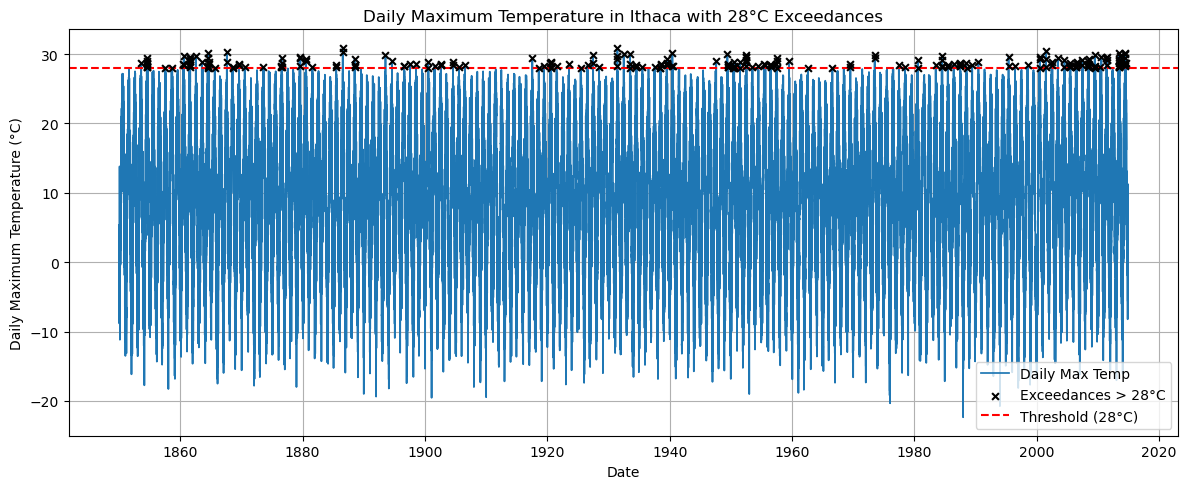

In [2016]:
# adapted from POT lecture, slide 14

# boolean for exceedances over 28°C
exceed_mask = ithaca_dat['TempMax'] > 28

# plot daily temperature time series
plt.figure(figsize=(12, 5))

plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], 
         label='Daily Max Temp', linewidth=1.25)

# plot exceedances with x markers
plt.scatter(
    ithaca_dat['Day'][exceed_mask],
    ithaca_dat['TempMax'][exceed_mask],
    color='black',
    label='Exceedances > 28°C',
    zorder=3,
    marker='x',
    s=24
)

# add horizontal threshold line at 28°C
plt.axhline(28, color='red', linestyle='--', 
            linewidth=1.5, label='Threshold (28°C)')

plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Maximum Temperature in Ithaca with 28°C Exceedances")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

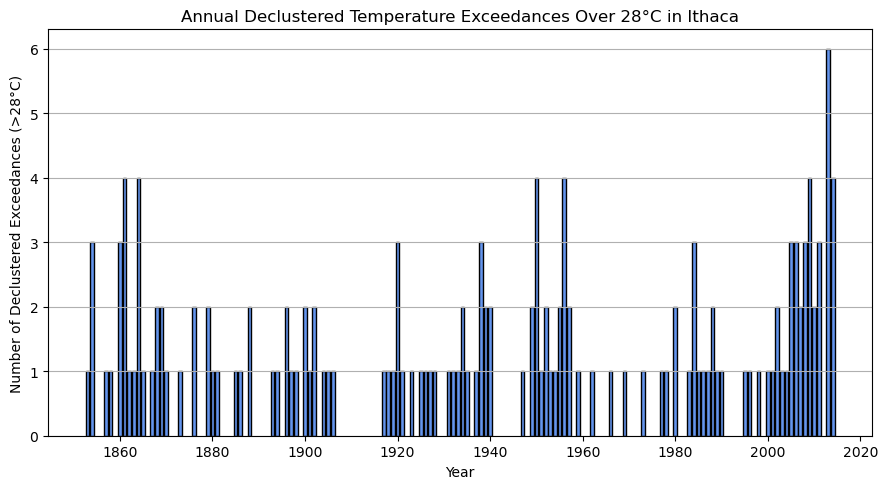

In [2017]:
# plot number of exceedances by year
# have they increased over time?

# count the declustered exceedances by year
declustered['Year'] = declustered['Day'].dt.year
exceed_count_by_year = declustered.groupby('Year').size()

# plot the number of exceedances by year
plt.figure(figsize=(9, 5))

plt.bar(exceed_count_by_year.index, exceed_count_by_year.values, 
        color='cornflowerblue', edgecolor='black')

plt.xlabel("Year")
plt.ylabel("Number of Declustered Exceedances (>28°C)")
plt.title("Annual Declustered Temperature Exceedances Over 28°C in Ithaca")
plt.grid(axis='y')
plt.tight_layout()

plt.show()

*Question: Have they (temperature exceedances over 28°C per year) increased over time?*

**RESPONSE: To tackle this problem, I first needed to figure out how to select the clustering window to distinguish independent events. To do this, I followed the approach in class and calculated the extremal index (θ) and reported the average cluster size as 1/θ, which I estimated to be 2 days. Based on this approach, when declustering using a mean time between clusters of 2 days, it does *not* appear that the temperature exceedances over 28°C per year have increased over time. This is because from the bar chart above, the heights of the bars seem pretty randomly dispersed and there is no clear pattern to the number of declustered exceedances over time. Although there is a slight uptick in 2013 (6 exceedances), I would not say the temperature exceedances over 28°C per year have steadily increased over time.**

#### **Stationary Poisson-GPD Model:**

In [2018]:
# Fit a stationary Poisson-GPD model for the exceedances 
# What does the GPD distribution look like?

threshold = 28

# calculate the amount by which each extreme event exceeds the threshold
exceedances = ithaca_dat[ithaca_dat['TempMax'] > threshold]['TempMax'] - threshold

# use genpareto function from scipy.stats 
# fit GPD: returns shape (ξ), location (μ), and scale (σ)
# fix loc to 0
shape_hat, loc_hat, scale_hat = genpareto.fit(exceedances, floc=0)  

print(f"---Estimated Stationary Poisson-GPD parameters:---")
print(f"  ξ (shape): {-shape_hat:.2f}")
print(f"  σ (scale): {scale_hat:.2f}")

---Estimated Stationary Poisson-GPD parameters:---
  ξ (shape): 0.19
  σ (scale): 0.85


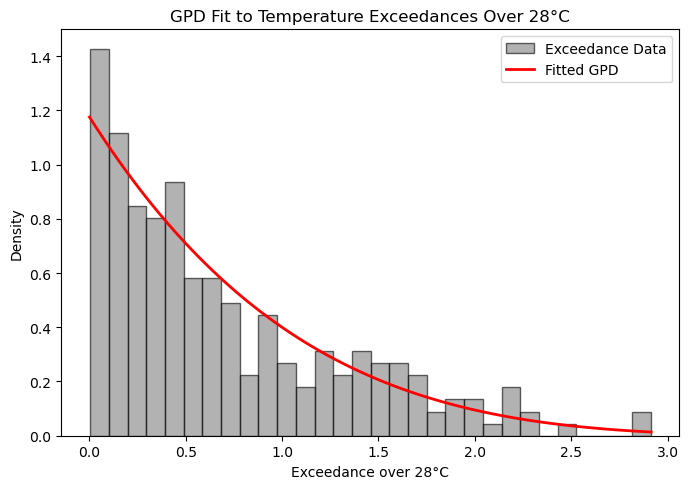

In [2019]:
# plot the GPD distribution 
# with histogram of exceedances over 28°C
plt.figure(figsize=(7, 5))

x = np.linspace(0, exceedances.max(), 100)
pdf_vals = genpareto.pdf(x, c=shape_hat, loc=loc_hat, scale=scale_hat)

plt.hist(exceedances, bins=30, density=True, alpha=0.6, 
         color='grey', edgecolor='black', label="Exceedance Data")

plt.plot(x, pdf_vals, 'r-', lw=2, label='Fitted GPD')

plt.xlabel("Exceedance over 28°C")
plt.ylabel("Density")
plt.title("GPD Fit to Temperature Exceedances Over 28°C")
plt.legend()
plt.tight_layout()

plt.show()

*Question: What does the GPD distribution look like?*

**RESPONSE: The fitted GPD appears to be heavy-tailed, with a right-skewed shape and gradually declines in density with larger exceedances over 28 degrees C. The distribution is unbounded and has a positive shape parameter (ξ > 0).**

#### **Stationary Poisson-GPD Model 100-yr Return Level & Comparison to Stationary GEV Model:**

In [2020]:
# From your model, estimate the 100-year return level. 
# How does it differ from the 100-year return period from 
# the stationary model in Problem 1? Why do you think it agrees or disagrees?

# adapted from POT lecture, slide 27

# fit GPD, re-defined from above 
ξ_hat, loc_hat, σ_hat = genpareto.fit(exceedances, floc=0)

# estimate Poisson rate λ (mean annual exceedance count)
exceed_counts = (ithaca_dat[ithaca_dat['TempMax'] > \
                            threshold].groupby('Year').size().reset_index(name='count'))

λ_hat = exceed_counts['count'].mean() # MLE of lambda for poisson is mean 

# estimate 100-year return level using Poisson-GPD formula
T = 100  # years
RL_100 = threshold + (σ_hat / ξ_hat) * ((T * λ_hat) ** ξ_hat - 1)

# print 100-yr return level
print(f"100-year return level (Poisson-GPD Model): {RL_100:.2f} °C")

100-year return level (Poisson-GPD Model): 30.92 °C


*Question: How does it (the 100-yr return level from the Poisson-GPD Model) differ from the 100-year return period from the (GEV) stationary model in Problem 1? Why do you think it agrees or disagrees?*

**RESPONSE: The 100-yr return level from the Poisson-GPD model is 30.92°C, while the 100-yr return level for the stationary GEV model is 30.78°C. So, the return levels are very similar from both approaches (difference of 0.14°C). I think these results agree with each other because I think I picked an appropriate block for the GEV model (annual maxima) as well as the threshold for the Poisson-GPD model (28°C). If these parameters/thresholds were not selected appropriately, I would expect the results from the two approaches to differ. So, overall, if implemented correctly, both approaches should converge to similar estimates for the 100-yr return levels.**

### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html)) contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone ($O_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide ($SO_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

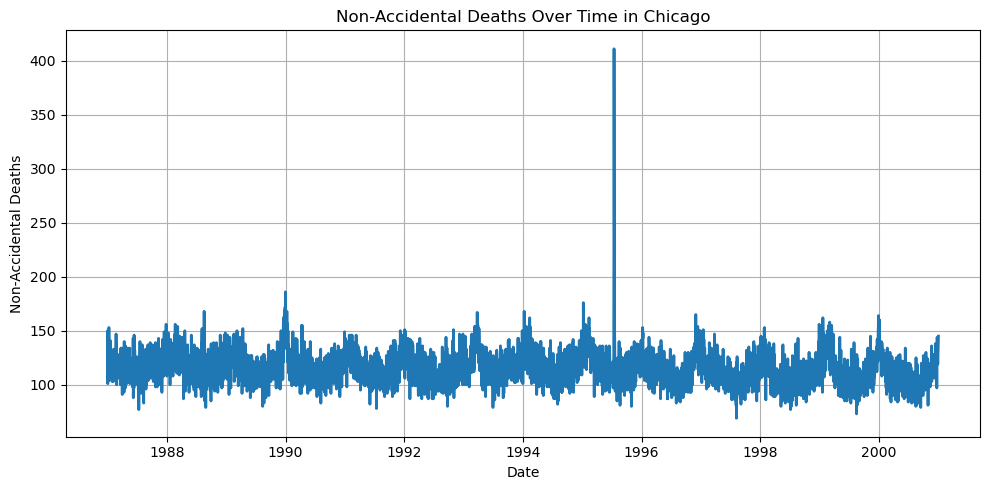

In [2021]:
# adapted from ChatGPT (see references)
# Read the CSV file with specified delimiter and NA values
chicago_dat = pd.read_csv("data/chicago.csv", delimiter=',', header=0, na_values="NA")

# Define the reference date
day_zero = datetime.strptime("1993-12-31", "%Y-%m-%d")

# Add fractional day offset (0.5 days = 12 hours), then compute full dates
chicago_dat['Date'] = chicago_dat['time'].apply(lambda t: day_zero + timedelta(days=t + 0.5))

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat['Date'], chicago_dat['death'], linewidth=2)
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths Over Time in Chicago")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

#### **Linearly Regress Number of Deaths vs. Time:**

In [2022]:
# deaths data is plotted above
# linearly regress the number of deaths against time 
# and report fitted regression coefficients

# first, drop NaNs in PM2.5 data
chicago_dat = chicago_dat.dropna(subset=['pm25median'])

# linear regression (death vs. time)
X = np.array((chicago_dat['time'])).reshape(-1, 1)  # time -> independent variable
y = np.array(chicago_dat['death'])  # deaths -> response variable

# fit the linear model
model = LinearRegression()
model.fit(X, y)

# get the regression coefficients
slope = model.coef_[0]
intercept = model.intercept_

# predict 
y_pred = model.predict(X)

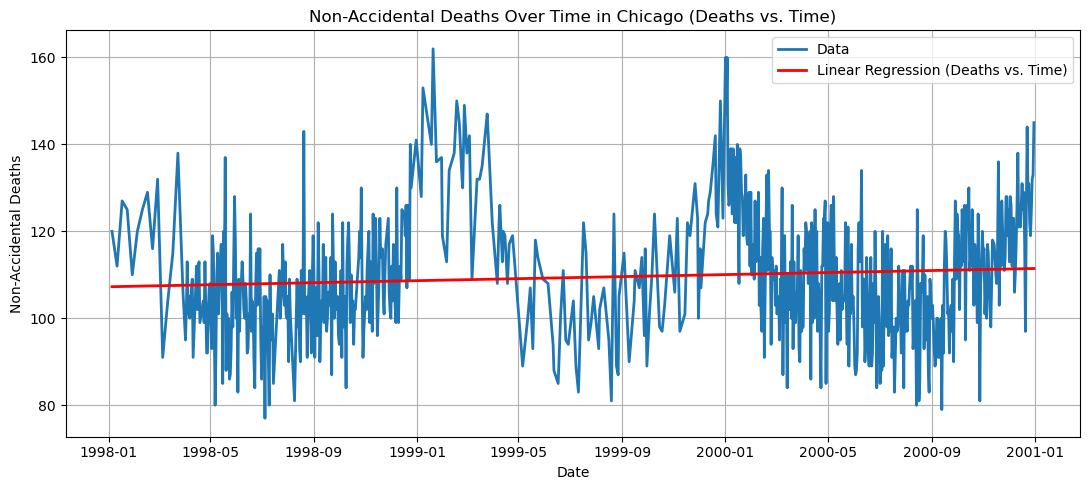

In [2023]:
# plot the data and the regression line
plt.figure(figsize=(11, 5))

plt.plot(chicago_dat['Date'], chicago_dat['death'], label="Data", linewidth=2)
plt.plot(chicago_dat['Date'], y_pred, color='red', 
         label="Linear Regression (Deaths vs. Time)", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths Over Time in Chicago (Deaths vs. Time)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2024]:
# print the regression coefficients
print(f"---Linear Regression Coefficients (Deaths vs Time):---")
print(f"Slope: {slope:.3f}")
print(f"Intercept (Initial number of deaths): {intercept:.3f}")

---Linear Regression Coefficients (Deaths vs Time):---
Slope: 0.004
Intercept (Initial number of deaths): 101.651


*Question: What does this regression (deaths vs. time) tell you?*

**NOTE: I dropped the NaNs in the PM2.5 column at the very beginning of this problem before fitting any regressions, and used this cleaned data frame to base the subsequent modeling exercises off of. This is because from the problem statement, we can assume the missing values can be treated as missing at random and thus dropped from the data set and in the linear regressions.**

**RESPONSE: From the above linear regression of deaths versus time, this tells me that with a slope of 0.004 deaths/day, on average, the number of non-accidental deaths in Chicago increased by ~0.004 deaths per day over the time period analyzed. This means there is a small positive trend in the mortality in Chicago over time. In terms of the intercept of 101.651 deaths, this is the estimated number of deaths at the starting point of the data set.**

#### **Linearly Regress Number of Deaths vs. Temperature:**

In [2025]:
# linearly regress the deaths data against temperature
# and add regression line to plot

# linear regression (death vs. temp)
X_2 = np.array((chicago_dat['tmpd'])).reshape(-1, 1)  # temp -> independent variable
y_2 = np.array(chicago_dat['death'])  # deaths -> response variable

# fit the linear model
model_2 = LinearRegression()
model_2.fit(X_2, y_2)

# get the regression coefficients
slope_2 = model_2.coef_[0]
intercept_2 = model_2.intercept_

# predict 
y_pred_temp = model_2.predict(X_2)

In [2026]:
# print the regression coefficients
print(f"---Linear Regression Coefficients (Deaths vs Temp):---")
print(f"Slope: {slope_2:.3f}")
print(f"Intercept (Initial number of deaths): {intercept_2:.3f}")

---Linear Regression Coefficients (Deaths vs Temp):---
Slope: -0.369
Intercept (Initial number of deaths): 129.209


*Question: What does this regression (deaths vs. temp) tell you about the influence of temperature?*

 **NOTE: Please see the complete plot below showing all three linear regression models compared to one another.**

**RESPONSE: From the above linear regression of deaths versus temperature, we estimate a slope of -0.369 deaths/°F. This means that for every 1°F increase in temperature, the model predicts a decrease of approximately 0.369 non-accidental deaths per day. Overall, this regression suggests that higher daily temperatures are associated with fewer non-accidental deaths in the data set period. However, I would be careful not to read too much into this result, as I am not sure a linear regression is the best model to fit these data to, and there may be confounding variables that we are not explicitly accounting for that may impact the results.**

#### **Linearly Regress Number of Deaths vs. Time & PM2.5 Density:**

In [2027]:
# Expand your previous model by regressing deaths against temperature 
# AND PM2.5 density. Report the coefficients and add this regression
# line to your plot

# expand the model
# predictor matrix with both temp and PM2.5 variables 
X_multi = chicago_dat[['tmpd', 'pm25median']].values 
y_multi = chicago_dat['death'].values  # response variable

# fit multiple linear regression
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# get regression coefficients
coefficients = model_multi.coef_
intercept3 = model_multi.intercept_

# predict 
y_pred_multi = model_multi.predict(X_multi)

# print results
print("---Linear Regression Coefficients (Deaths vs. Temp and PM2.5 Density):---")
print(f"Intercept: {intercept3:.4f}")
print(f"Coefficient for Temperature (tmpd): {coefficients[0]:.3f}")
print(f"Coefficient for PM2.5 (pm25median): {coefficients[1]:.3f}")

---Linear Regression Coefficients (Deaths vs. Temp and PM2.5 Density):---
Intercept: 129.2939
Coefficient for Temperature (tmpd): -0.371
Coefficient for PM2.5 (pm25median): 0.215


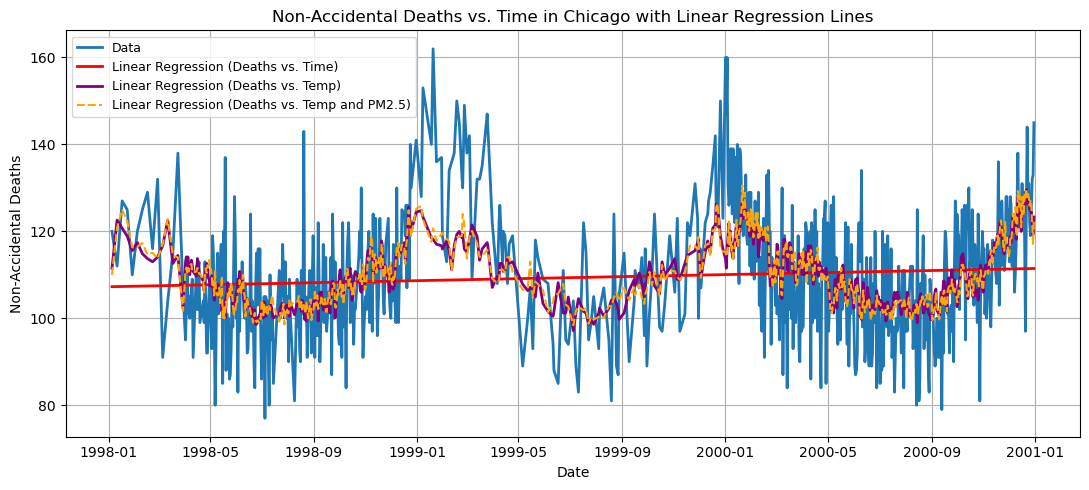

In [2028]:
# plot the data and all the regression lines
plt.figure(figsize=(11, 5))

# data 
plt.plot(chicago_dat['Date'], chicago_dat['death'], label="Data", linewidth=2)

# model 1: deaths vs. time 
plt.plot(chicago_dat['Date'], y_pred, color='red', 
         label="Linear Regression (Deaths vs. Time)", linewidth=2)

# model 2: deaths vs. temp
plt.plot(chicago_dat['Date'], y_pred_temp, color='purple', 
         label="Linear Regression (Deaths vs. Temp)", linewidth=2)

# model 3: deaths vs. temp and pm2.5 density 
plt.plot(chicago_dat['Date'], y_pred_multi, color='orange', 
         label="Linear Regression (Deaths vs. Temp and PM2.5)", linewidth=1.5,
         linestyle="--")

plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths vs. Time in Chicago with Linear Regression Lines")
plt.legend(loc = "upper left", fontsize=9)
plt.grid(True)
plt.tight_layout()

plt.show()

#### **Compute AIC for the Three Fitted Linear Regression Models:**

In [2029]:
# Compute the AICs for the three fitted model and compare them. What
# do they tell you about the relative evidence for the influence of
# temperature and PM2.5 density on deaths? How do your conclusions
# based on AIC compare to those you might draw from your regression
# coefficients and plots?

# first model: deaths vs. time
# add intercept to X
X_sm1 = sm.add_constant(X)
model_sm1 = sm.OLS(y, X_sm1).fit()
print("AIC from Linear Regression (Deaths vs. Time):", 
      model_sm1.aic.round(1))

# second model: deaths vs. temp
# add intercept to X
X_sm2 = sm.add_constant(X_2)
model_sm2 = sm.OLS(y_2, X_sm2).fit()
print("AIC from Linear Regression (Deaths vs. Temp):", 
      model_sm2.aic.round(1))

# third model: deaths vs. temp and pm2.5 density  
# add intercept to X
X_sm3 = sm.add_constant(X_multi)
model_sm3 = sm.OLS(y_multi, X_sm3).fit()
print("AIC from Linear Regression (Deaths vs. Temp and PM2.5):", 
      model_sm3.aic.round(1))

AIC from Linear Regression (Deaths vs. Time): 5916.1
AIC from Linear Regression (Deaths vs. Temp): 5727.0
AIC from Linear Regression (Deaths vs. Temp and PM2.5): 5712.3


*Question: What do the AICs from all 3 models tell you about the relative evidence for the influence of temperature and PM2.5 density on deaths? How do your conclusions based on AIC compare to those you might draw from your regression coefficients and plots?*

**RESPONSE: Recall that the AIC helps us compare models, where a lower AIC is preferred. Based on the AICs from all three models, the model with temperature *and* PM2.5 density has the lowest AIC (5,712.3), which suggests it is the best among the three models. The model with only temperature as a predictor (AIC = 5727.0) is better than the model with only time as a predictor (AIC = 5916.1), suggesting temperature alone explains more variability in deaths than just time. Moreover, the AIC drops by ~15 units when adding PM2.5 to the temperature model, which is evidence that the PM2.5 variable further improves the model performance. Looking at the plots, we see that time alone does not capture the variability in non-accidental deaths very well, such as seasonal trends or daily variability, while the multi-variate model with temperature and PM2.5 tracks the non-accidental observed deaths data more closely. However, if we only looked at the plots, we might think that the regressions of deaths vs. temperature and deaths vs. temperature and PM2.5 density are very close in performance (i.e., we might think PM2.5 density does not explain much in terms of mortality), as the regression lines overlap with one another considerably (orange and purple lines). As for the regression coefficients, we see that the coefficient for temperature does not change that much going from the temperature only model to when we add PM2.5 as a predictor, which also might lead us to conclude that PM2.5 density is not that important of a predictor in predicting mortality in Chicago. Thus, overall, the AIC offers a more robust basis for model comparison here, and supports the conclusion that both temperature *and* PM2.5 density are important predictors of daily mortality in Chicago.**

## References and Generative AI Acknowledgement 

BEE-6310 *Environmental Statistics and Learning* Class Notes - "Lecture 7: Selecting a Probability Model." Fall 2024 Semester. 

OpenAI. (2025). ChatGPT (April 14 version) [Large language model]. https://openai.com/chatgpt [Accessed 14 April 2025]. 

- Problem 0: Setting up packages
    - Prompt I asked ChatGPT: "Convert these Julia packages to Python". That is, I asked it to convert the provided Julia packages to Python.
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 1: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 3: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)
plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

scipy.stats.genextreme documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genextreme.html. [Accessed 29 April 2025]. 

scipy.stats.genpareto documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genpareto.html. [Accessed 01 May 2025].